 """
hierarchical_production.py - Production Hierarchical System

Architecture:
- Base: 4 validated agents (tech_PPO, tech_SAC, sent_PPO, sent_SAC)
- Super: Learns to dynamically weight all 4 base agents
- Meta: Refines Super allocation for final portfolio

Uses best models from walk-forward validation
"""

              ┌─────────────────────────────────────────────┐
              │           META AGENT (Top Level)            │
              │      "Portfolio manager - final layer"      │
              │                                             │
              │  Inputs: Super Agent weights  + regime indicators              │
              │  Output: Final portfolio allocation         │
              └──────────────────┬──────────────────────────┘
                                 │
              ┌──────────────────▼──────────────────────────┐
              │         SUPER AGENT (Middle Level)          │
              │   "Blends 4 base agents dynamically"        │
              │                                             │
              │  Inputs: tech_PPO, tech_SAC, sent_PPO,      │
              │          sent_SAC weights                   │
              │  Output: Blended allocation                 │
              └─┬────────┬──────────┬──────────┬────────────┘
                │        │          │          │
         ┌──────▼──┐ ┌──▼──────┐ ┌─▼────────┐ ┌▼─────────┐
         │tech_PPO │ │tech_SAC │ │sent_PPO  │ │sent_SAC  │
         │from     │ │from     │ │from      │ │from      │
         │walk-fwd │ │walk-fwd │ │walk-fwd  │ │walk-fwd  │
         └─────────┘ └─────────┘ └──────────┘ └──────────┘

In [1]:
import gymnasium
import datetime
import pandas as pd
from base_agents_helper import *

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Timestamp: 2025-10-15 10:37:06

Loading data...
✓ Loaded price data: (129, 10)
✓ Loaded technical features: (129, 110)
✓ Loaded sentiment features: (129, 53)

Validating data...
Price data range: 2015-02-28 to 2025-10-31
Missing values - Prices: 0
Missing values - Technical: 0
Missing values - Sentiment: 0
WALK-FORWARD VALIDATION (FINAL FIXED VERSION)

Configuration:
  Train window: 60 months
  Test window:  12 months
  Timesteps:    30000
  Max position: 30%
  Algorithms:   ['PPO', 'SAC']
  Agent types:  ['technical', 'sentiment']
  Save models:  True

Total data: 129 months
Number of windows: 5
Date range: 2015-02-28 to 2025-10-31
✓ Created models directory

WINDOW 1/5
Train: 2015-02-28 to 2020-01-31 (60 months)
Test:  2020-02-29 to 2021-01-31 (12 months)

  Training technical_PPO...
    Starting training for 30000 timesteps...
    ✓ Training completed
    Train Sharpe: 15.436
    Test Sharpe:  15.345
    Test Return:  212.5%
    Test Max DD:  8.4%
    Gap:          0.6%
    ✓ Saved 

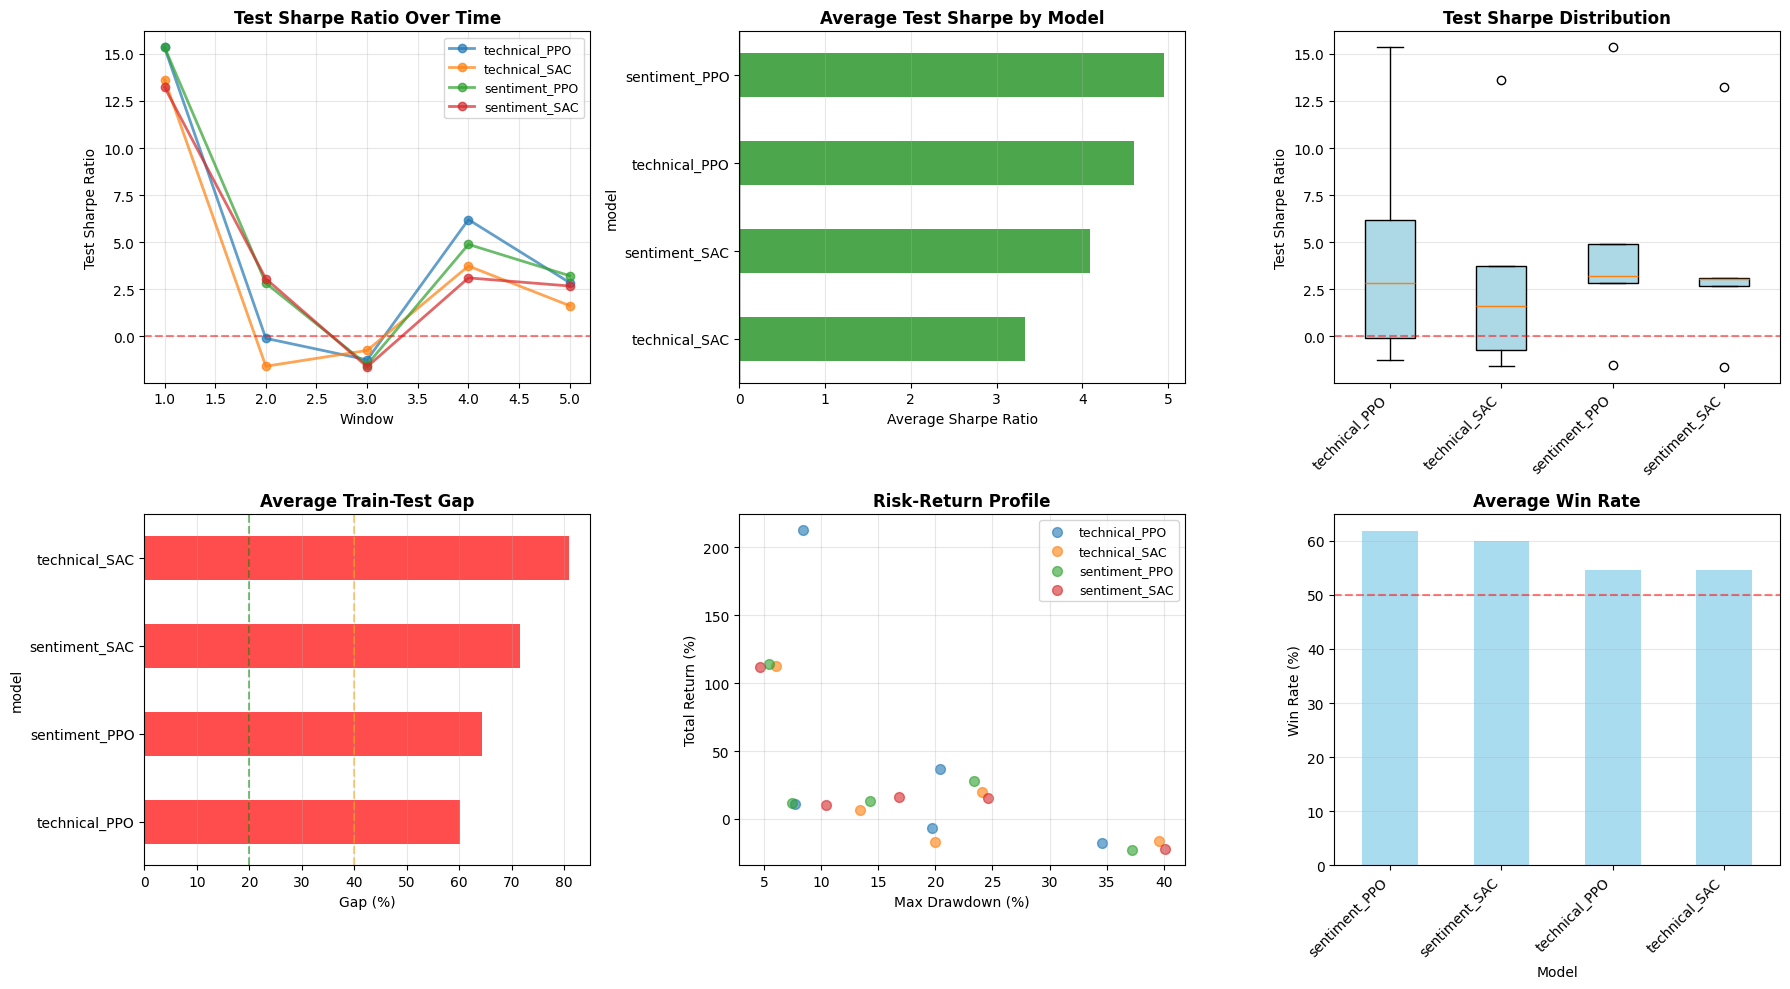


✓ Saved results: walk_forward_results_20251015_105943.csv


In [2]:

print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("\nLoading data...")
price_data = pd.read_csv('data/price_data.csv', index_col=0, parse_dates=True)
technical_features = pd.read_csv('data/technical_features.csv', index_col=0, parse_dates=True)
sentiment_features = pd.read_csv('data/sentiment_features.csv', index_col=0, parse_dates=True)

print(f"✓ Loaded price data: {price_data.shape}")
print(f"✓ Loaded technical features: {technical_features.shape}")
print(f"✓ Loaded sentiment features: {sentiment_features.shape}")

# Validate data
print("\nValidating data...")
print(f"Price data range: {price_data.index[0].date()} to {price_data.index[-1].date()}")
print(f"Missing values - Prices: {price_data.isnull().sum().sum()}")
print(f"Missing values - Technical: {technical_features.isnull().sum().sum()}")
print(f"Missing values - Sentiment: {sentiment_features.isnull().sum().sum()}")


results_df, windows_details, best_models = walk_forward_validation(
    price_data=price_data,
    tech_features=technical_features,
    sent_features=sentiment_features,
    train_size=60,      # 5 years
    test_size=12,       # 1 year
    timesteps=30000,    # Reduced for faster testing
    max_position=0.30,  # 30% max position
    algorithms=['PPO', 'SAC'],
    agent_types=['technical', 'sentiment'],
    save_models=True,
    verbose=1
)



summary = analyze_walkforward_results(results_df, windows_details)

# Save results
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
results_filename = f'walk_forward_results_{timestamp}.csv'
results_df.to_csv(results_filename, index=False)
print(f"\n✓ Saved results: {results_filename}")


In [3]:
# Final recommendations
print("FINAL RECOMMENDATION")

best_model = results_df.groupby('model')['test_sharpe'].mean().idxmax()
best_sharpe = results_df.groupby('model')['test_sharpe'].mean().max()
best_positive_rate = (results_df[results_df['model'] == best_model]['test_sharpe'] > 0).mean() * 100

if best_sharpe > 0.8 and best_positive_rate > 60:
    print(f"\nSTRONG: Deploy {best_model}")
    print(f"   Sharpe: {best_sharpe:.3f}, Consistency: {best_positive_rate:.0f}%")
elif best_sharpe > 0.5:
    print(f"\nMODERATE: {best_model} shows acceptable performance")
    print(f"   Consider further optimization")
else:
    print(f"\nWEAK: All models underperforming")
    print(f"   Revisit feature engineering and model design")

# Summary to the final recommendation
print(f"\nSummary Statistics:")
summary


FINAL RECOMMENDATION

STRONG: Deploy sentiment_PPO
   Sharpe: 4.948, Consistency: 80%

Summary Statistics:


test_sharpe                       test_return         \
                     mean    std    min     max        mean    std   
model                                                                
sentiment_PPO       4.948  6.278 -1.517  15.354       0.290  0.511   
sentiment_SAC       4.084  5.489 -1.629  13.239       0.263  0.501   
technical_PPO       4.601  6.665 -1.260  15.345       0.473  0.947   
technical_SAC       3.325  6.133 -1.601  13.641       0.212  0.535   

              test_max_dd        test_volatility train_test_gap  
                     mean    max            mean           mean  
model                                                            
sentiment_PPO       0.175  0.372           1.412         64.302  
sentiment_SAC       0.193  0.401           1.479         71.636  
technical_PPO       0.182  0.346           1.591         60.076  
technical_SAC       0.206  0.396           1.651         80.875

## Portfolio Allocation Visualization

Visualizing current portfolio allocation for each of the 4 best base models.


In [4]:
asset_names = price_data.columns.tolist()

print(f"Loaded data: {price_data.shape[0]} months, {len(asset_names)} assets")
print(f"Assets: {asset_names}")


Loaded data: 129 months, 10 assets
Assets: ['NVDA', 'MU', 'MRVL', 'MSFT', 'ASML', 'AEM', 'AMD', 'GOOGL', 'PLUG', 'INGN']


In [5]:
# Load best models and get their final portfolio weights

models_info = {
    'technical_PPO': {'path': 'models/best_technical_PPO.zip', 'env_type': 'technical'},
    'technical_SAC': {'path': 'models/best_technical_SAC.zip', 'env_type': 'technical'},
    'sentiment_PPO': {'path': 'models/best_sentiment_PPO.zip', 'env_type': 'sentiment'},
    'sentiment_SAC': {'path': 'models/best_sentiment_SAC.zip', 'env_type': 'sentiment'},
}

allocations = {}

for model_name, info in models_info.items():
    try:
        # Load model
        if 'PPO' in model_name:
            model = PPO.load(info['path'])
        else:
            model = SAC.load(info['path'])
        
        # Create environment using existing classes from cell 2
        if info['env_type'] == 'technical':
            env = TechnicalEnv(price_data, technical_features, max_position=0.30)
        else:
            env = SentimentEnv(price_data, sentiment_features, max_position=0.30)
        
        # Get current observation (most recent data)
        obs, _ = env.reset()
        
        # Get model's action
        action, _ = model.predict(obs, deterministic=True)
        
        # Convert action to weights (same logic as in training environment)
        action = (action + 1.0) / 2.0  # Rescale from [-1, 1] to [0, 1]
        action = np.clip(action, 0, 1)
        total = action.sum()
        weights = action / total if total > 1e-6 else np.ones(len(action)) / len(action)
        weights = np.clip(weights, 0, 0.30)  # Max 30% per asset
        weights = weights / weights.sum()  # Renormalize
        
        allocations[model_name] = weights
        
        print(f"{model_name:20s}: Loaded ✓")
        
    except Exception as e:
        print(f"{model_name:20s}: Error - {e}")

print(f"\nLoaded {len(allocations)}/4 models successfully")

technical_PPO       : Loaded ✓
technical_SAC       : Loaded ✓
sentiment_PPO       : Loaded ✓
sentiment_SAC       : Loaded ✓

Loaded 4/4 models successfully


In [6]:
# Create a DataFrame for easy analysis

if len(allocations) > 0:
    # Convert to DataFrame
    weights_df = pd.DataFrame(allocations, index=asset_names)
    weights_df = weights_df * 100  # Convert to percentages
    
    print("PORTFOLIO WEIGHTS DATAFRAME (%):")
    print("="*50)
    print(weights_df.round(2))
    
    # Save to CSV
    weights_df.to_csv('final_portfolio_weights_by_base_models.csv')
    print(f"\n✓ Saved weights to: final_portfolio_weights_by_base_models.csv")
    
    # Summary statistics
    print(f"\nSUMMARY STATISTICS:")
    print(f"Average weight per asset:")
    print(weights_df.mean().round(2))
    
    print(f"\nWeight concentration (max weight per model):")
    print(weights_df.max().round(2))
    
    print(f"\nNumber of assets with >5% allocation per model:")
    print((weights_df > 5).sum())
else:
    print("No allocations available for DataFrame creation")


PORTFOLIO WEIGHTS DATAFRAME (%):
       technical_PPO  technical_SAC  sentiment_PPO  sentiment_SAC
NVDA       20.200001      11.180000          12.19          14.31
MU          5.670000       3.510000           6.21           9.99
MRVL        5.650000       2.480000          10.38          14.05
MSFT       11.460000      14.850000           9.69          13.75
ASML       10.150000      16.850000           9.71           5.65
AEM         7.360000       3.380000          10.61           0.41
AMD         4.020000      18.219999          11.18          14.01
GOOGL      16.309999       2.320000          11.77          11.68
PLUG        4.660000       0.570000           6.83           0.65
INGN       14.520000      26.639999          11.43          15.50

✓ Saved weights to: final_portfolio_weights_by_base_models.csv

SUMMARY STATISTICS:
Average weight per asset:
technical_PPO    10.0
technical_SAC    10.0
sentiment_PPO    10.0
sentiment_SAC    10.0
dtype: float32

Weight concentration (max 

Saved: plots/portfolio_allocations_individual.png


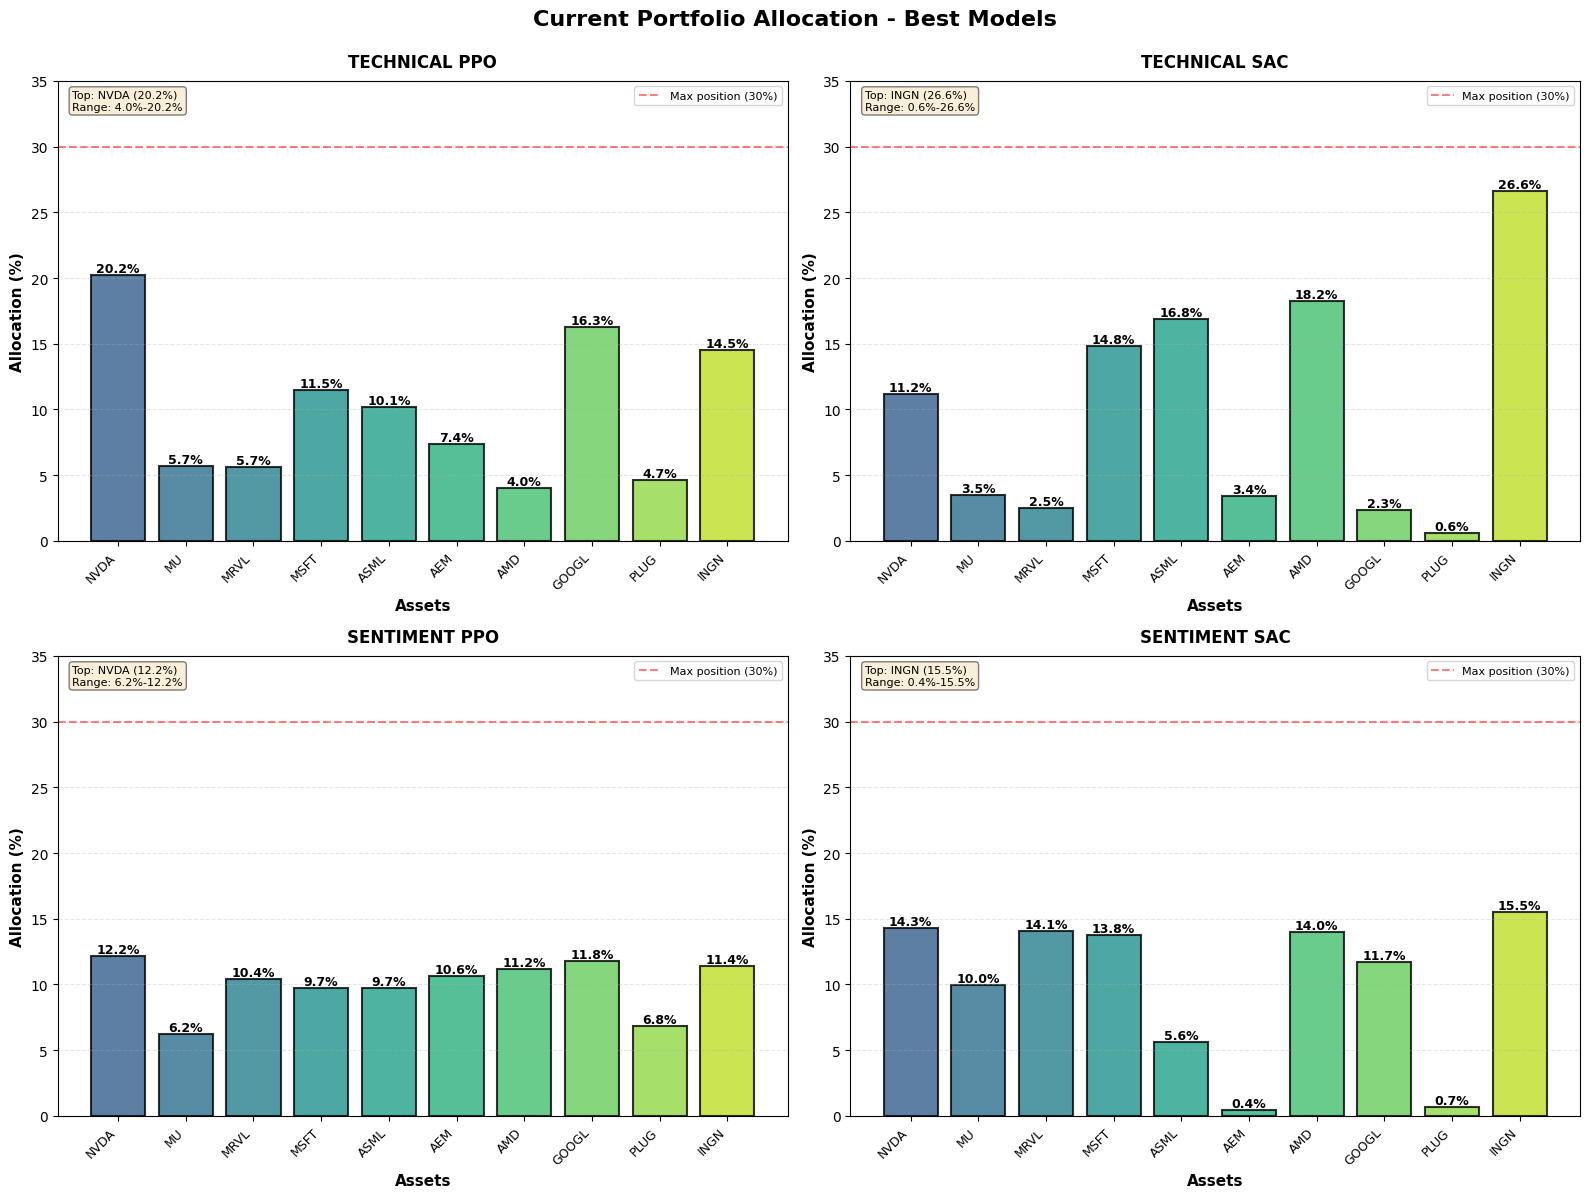

In [7]:
# Visualize portfolio allocations for each model

if len(allocations) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Current Portfolio Allocation - Best Models', fontsize=16, fontweight='bold', y=0.995)

    models_order = ['technical_PPO', 'technical_SAC', 'sentiment_PPO', 'sentiment_SAC']
    positions = [(0, 0), (0, 1), (1, 0), (1, 1)]

    for idx, (model_name, pos) in enumerate(zip(models_order, positions)):
        ax = axes[pos]
        
        if model_name in allocations:
            weights = allocations[model_name]
            
            # Create bar plot
            colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(asset_names)))
            bars = ax.bar(range(len(asset_names)), weights * 100, color=colors, alpha=0.8, 
                          edgecolor='black', linewidth=1.5)
            
            # Add value labels on bars
            for bar, weight in zip(bars, weights):
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{weight*100:.1f}%', ha='center', va='bottom', 
                       fontsize=9, fontweight='bold')
            
            # Styling
            ax.set_xlabel('Assets', fontsize=11, fontweight='bold')
            ax.set_ylabel('Allocation (%)', fontsize=11, fontweight='bold')
            ax.set_title(f'{model_name.replace("_", " ").upper()}', fontsize=12, 
                        fontweight='bold', pad=10)
            ax.set_xticks(range(len(asset_names)))
            ax.set_xticklabels(asset_names, rotation=45, ha='right', fontsize=9)
            ax.grid(True, alpha=0.3, axis='y', linestyle='--')
            ax.set_ylim([0, 35])
            ax.axhline(y=30, color='red', linestyle='--', alpha=0.5, linewidth=1.5, 
                      label='Max position (30%)')
            ax.legend(loc='upper right', fontsize=8)
            
            # Add summary text
            max_weight = weights.max() * 100
            min_weight = weights.min() * 100
            top_asset = asset_names[np.argmax(weights)]
            summary = f'Top: {top_asset} ({max_weight:.1f}%)\nRange: {min_weight:.1f}%-{max_weight:.1f}%'
            ax.text(0.02, 0.98, summary, transform=ax.transAxes, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5), fontsize=8)
        else:
            ax.text(0.5, 0.5, 'Model not available', ha='center', va='center', fontsize=12)
            ax.set_title(f'{model_name.replace("_", " ").upper()}', fontsize=12, fontweight='bold')

    plt.tight_layout()
    plt.savefig('plots/portfolio_allocations_individual.png', dpi=300, bbox_inches='tight')
    print("Saved: plots/portfolio_allocations_individual.png")
    plt.show()
else:
    print("No allocations available to visualize")

ENSEMBLE PORTFOLIO (Equal Weight Average of All 4 Models)
   Asset  Ensemble_Weight  Technical_PPO  Technical_SAC  Sentiment_PPO  \
0   NVDA            14.47      20.200001      11.180000          12.19   
1     MU             6.34       5.670000       3.510000           6.21   
2   MRVL             8.14       5.650000       2.480000          10.38   
3   MSFT            12.44      11.460000      14.850000           9.69   
4   ASML            10.59      10.150000      16.850000           9.71   
5    AEM             5.44       7.360000       3.380000          10.61   
6    AMD            11.86       4.020000      18.219999          11.18   
7  GOOGL            10.52      16.309999       2.320000          11.77   
8   PLUG             3.18       4.660000       0.570000           6.83   
9   INGN            17.02      14.520000      26.639999          11.43   

   Sentiment_SAC  
0          14.31  
1           9.99  
2          14.05  
3          13.75  
4           5.65  
5           0

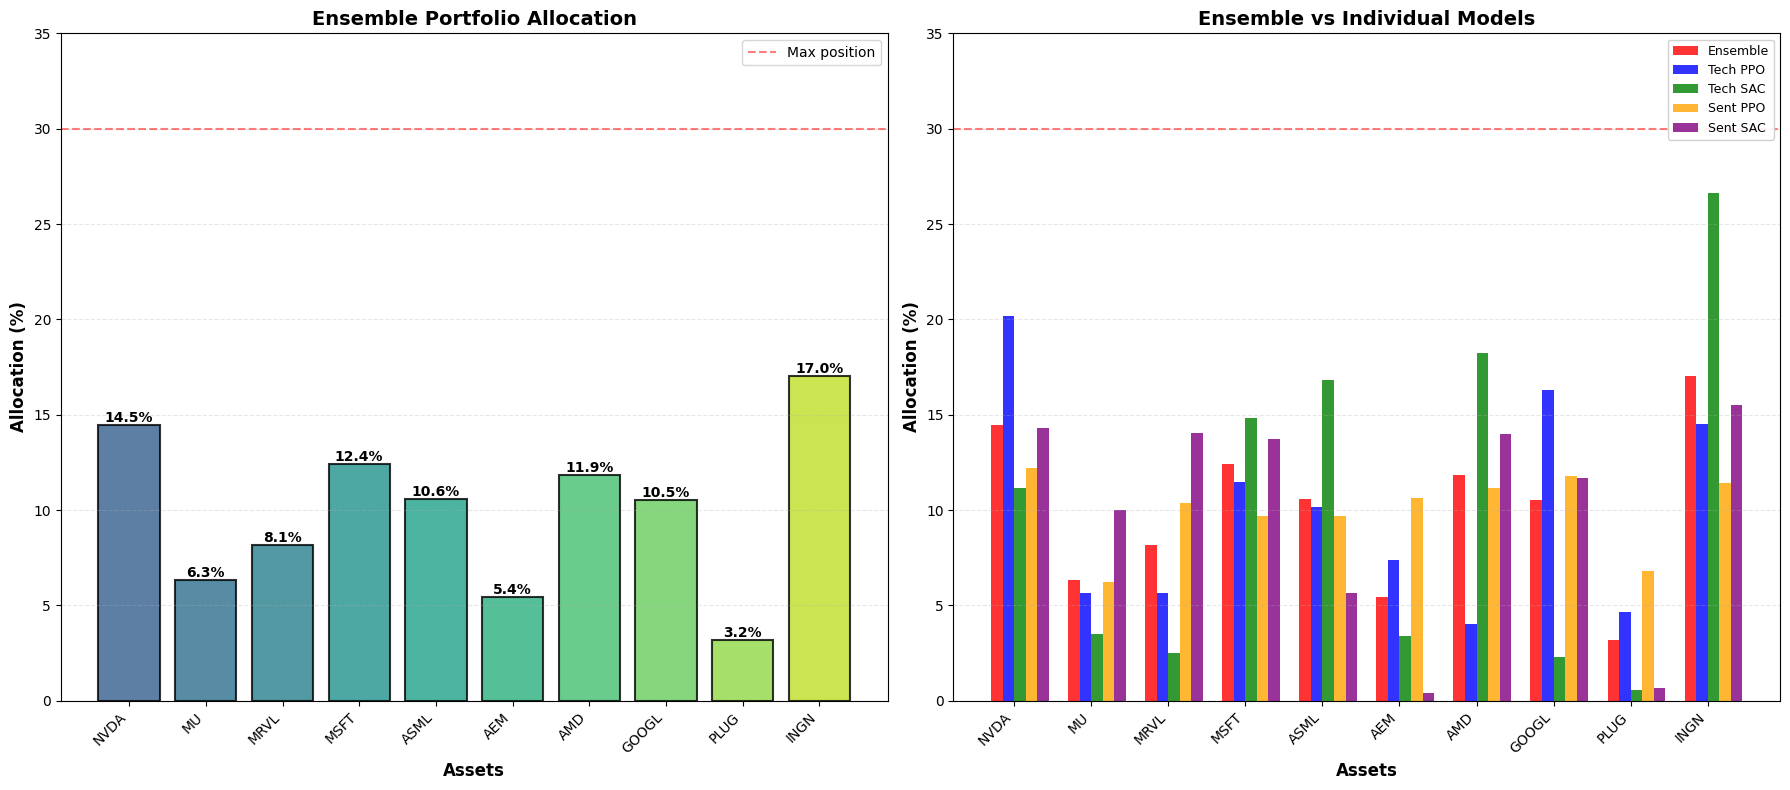

In [8]:
# Create ensemble portfolio from all 4 models
# Equal weight ensemble (simple average)
ensemble_weights = np.mean(list(allocations.values()), axis=0)

# Create ensemble DataFrame
ensemble_df = pd.DataFrame({
    'Asset': asset_names,
    'Ensemble_Weight': ensemble_weights * 100,
    'Technical_PPO': allocations['technical_PPO'] * 100,
    'Technical_SAC': allocations['technical_SAC'] * 100,
    'Sentiment_PPO': allocations['sentiment_PPO'] * 100,
    'Sentiment_SAC': allocations['sentiment_SAC'] * 100
})

print("="*80)
print("ENSEMBLE PORTFOLIO (Equal Weight Average of All 4 Models)")
print("="*80)
print(ensemble_df.round(2))

# Save ensemble weights
ensemble_df.to_csv('ensemble_portfolio_weights.csv', index=False)
print(f"\n✓ Saved ensemble weights to: ensemble_portfolio_weights.csv")

# Visualize ensemble vs individual models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Left plot: Ensemble allocation
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(asset_names)))
bars = ax1.bar(range(len(asset_names)), ensemble_weights * 100, color=colors, alpha=0.8, 
                edgecolor='black', linewidth=1.5)

# Add value labels
for bar, weight in zip(bars, ensemble_weights):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{weight*100:.1f}%', ha='center', va='bottom', 
            fontsize=10, fontweight='bold')

ax1.set_xlabel('Assets', fontsize=12, fontweight='bold')
ax1.set_ylabel('Allocation (%)', fontsize=12, fontweight='bold')
ax1.set_title('Ensemble Portfolio Allocation', fontsize=14, fontweight='bold')
ax1.set_xticks(range(len(asset_names)))
ax1.set_xticklabels(asset_names, rotation=45, ha='right', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')
ax1.set_ylim([0, 35])
ax1.axhline(y=30, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label='Max position')
ax1.legend(loc='upper right', fontsize=10)

# Right plot: Comparison of ensemble vs individual models
x = np.arange(len(asset_names))
width = 0.15

ax2.bar(x - 1.5*width, ensemble_weights * 100, width, label='Ensemble', alpha=0.8, color='red')
ax2.bar(x - 0.5*width, allocations['technical_PPO'] * 100, width, label='Tech PPO', alpha=0.8, color='blue')
ax2.bar(x + 0.5*width, allocations['technical_SAC'] * 100, width, label='Tech SAC', alpha=0.8, color='green')
ax2.bar(x + 1.5*width, allocations['sentiment_PPO'] * 100, width, label='Sent PPO', alpha=0.8, color='orange')
ax2.bar(x + 2.5*width, allocations['sentiment_SAC'] * 100, width, label='Sent SAC', alpha=0.8, color='purple')

ax2.set_xlabel('Assets', fontsize=12, fontweight='bold')
ax2.set_ylabel('Allocation (%)', fontsize=12, fontweight='bold')
ax2.set_title('Ensemble vs Individual Models', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(asset_names, rotation=45, ha='right', fontsize=10)
ax2.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')
ax2.axhline(y=30, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax2.set_ylim([0, 35])

plt.tight_layout()
plt.savefig('plots/ensemble_portfolio.png', dpi=300, bbox_inches='tight')
print("Saved: plots/ensemble_portfolio.png")
plt.show()


In [9]:
# Ensemble statistics
print(f"\nENSEMBLE STATISTICS:")
print(f"Total allocation: {ensemble_weights.sum()*100:.2f}%")
print(f"Max single asset weight: {ensemble_weights.max()*100:.2f}%")
print(f"Min single asset weight: {ensemble_weights.min()*100:.2f}%")
print(f"Number of assets with >5% allocation: {(ensemble_weights > 0.05).sum()}")
print(f"Number of assets with >10% allocation: {(ensemble_weights > 0.10).sum()}")

# Top 5 holdings
sorted_ensemble = sorted(zip(asset_names, ensemble_weights), key=lambda x: x[1], reverse=True)
print(f"\nTop 5 Holdings:")
for i, (asset, weight) in enumerate(sorted_ensemble[:5]):
    print(f"  {i+1}. {asset}: {weight*100:.1f}%")



ENSEMBLE STATISTICS:
Total allocation: 100.00%
Max single asset weight: 17.02%
Min single asset weight: 3.18%
Number of assets with >5% allocation: 9
Number of assets with >10% allocation: 6

Top 5 Holdings:
  1. INGN: 17.0%
  2. NVDA: 14.5%
  3. MSFT: 12.4%
  4. AMD: 11.9%
  5. ASML: 10.6%
